# Visual inspection of Raman spectral preprocessing

This notebook inspects each preprocessing stage used before model training:

- Raw spectra
- Cosmic-ray spike removal
- Savitzky-Golay smoothing
- IA-WPLS baseline correction
- L2 normalization
- Stratified train/validation/test split

In [12]:
from __future__ import annotations

import json
import sys
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'axes.linewidth': 0.8,
    'axes.grid': False,
    'axes.unicode_minus': False,
})



def find_project_root(start: Optional[Path] = None) -> Path:
    path = start or Path.cwd()
    for candidate in [path, *path.parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'data').exists():
            return candidate
    raise FileNotFoundError('Cannot locate project root.')

ROOT = find_project_root()
sys.path.insert(0, str(ROOT / 'code'))

from utils.config import load_yaml, resolve_path, set_seed
from data.prepare_data import (
    LABEL_COLUMN,
    feature_columns,
    iawpls_baseline,
    preprocess_spectra,
    read_raw_spectra,
    remove_cosmic_rays,
    save_npz,
    save_split_csvs,
    stratified_split,
)

DATA2_DIR = ROOT / 'data2'
DATA2_DIR.mkdir(parents=True, exist_ok=True)

config_path = ROOT / 'configs' / 'dataset.yaml'
config = load_yaml(config_path)
seed = int(config.get('project', {}).get('seed', 42))
set_seed(seed)

print('Project root:', ROOT)
print('Config:', config_path)
print('Intermediate output directory:', DATA2_DIR)


Project root: C:\Users\19447\Desktop\LungAdenocarcinoma_Raman_Diffusion_Reproduction
Config: C:\Users\19447\Desktop\LungAdenocarcinoma_Raman_Diffusion_Reproduction\configs\dataset.yaml
Intermediate output directory: C:\Users\19447\Desktop\LungAdenocarcinoma_Raman_Diffusion_Reproduction\data2


In [13]:
raw_df = read_raw_spectra(config, ROOT)
columns = feature_columns(raw_df)
x_axis = np.array([float(c) for c in columns])

display(raw_df.head())
print('Shape:', raw_df.shape)
print(raw_df[LABEL_COLUMN].value_counts())


,label,600.106,600.859,601.612,602.365,603.118,603.87,604.623,605.375,606.127,...,1794.37,1794.97,1795.57,1796.17,1796.77,1797.38,1797.98,1798.58,1799.18,1799.78
0,healthy,4832.67,4893.33,4840.67,4887.33,4789.33,4836.67,4856.67,4806.0,4862.67,...,1182.00,1171.33,1188.00,1186.67,1182.00,1179.33,1194.00,1192.67,1160.00,1186.67
1,healthy,17981.30,17970.70,17965.30,17936.70,18002.70,17900.70,17982.00,17956.0,18047.30,...,4236.00,4236.00,4232.00,4211.33,4168.00,4160.00,4182.00,4181.33,4179.33,4163.33
2,healthy,19573.50,19553.50,19485.00,19591.50,19355.50,19563.50,19466.00,19495.5,19523.50,...,4715.50,4734.50,4723.00,4753.00,4688.00,4682.50,4719.50,4686.50,4663.50,4668.00
3,healthy,14392.70,14498.00,14400.70,14372.70,14400.70,14477.30,14482.00,14404.0,14476.70,...,3847.33,3845.33,3831.33,3904.00,3820.00,3836.67,3818.00,3811.33,3816.67,3803.33
4,healthy,18027.30,18192.00,18044.00,18123.30,17995.30,18082.70,18075.30,18139.3,18022.70,...,4586.00,4628.67,4549.33,4591.33,4586.67,4585.33,4582.67,4562.00,4523.33,4523.33


Shape: (180, 1785)
label
lung_adenocarcinoma    93
healthy                87
Name: count, dtype: int64


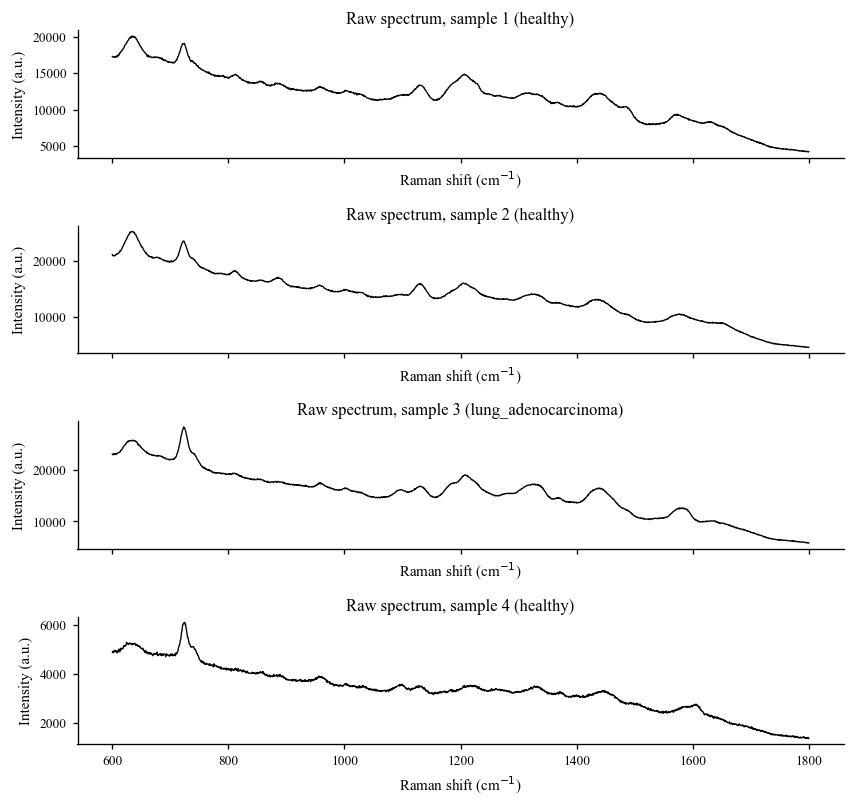

In [14]:
def style_axis(ax) -> None:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=3, width=0.8)
    ax.set_xlabel('Raman shift (cm$^{-1}$)')
    ax.set_ylabel('Intensity (a.u.)')


def plot_random_spectra(df: pd.DataFrame, title: str, n: int = 4, random_state: int = 42) -> None:
    sampled = df.sample(n=min(n, len(df)), random_state=random_state).reset_index(drop=True)
    fig, axes = plt.subplots(len(sampled), 1, figsize=(7.2, 1.7 * len(sampled)), sharex=True)
    if len(sampled) == 1:
        axes = np.array([axes])
    for row_idx, (_, row) in enumerate(sampled.iterrows()):
        label = row[LABEL_COLUMN]
        spectrum = row[columns].to_numpy(dtype=float)
        axes[row_idx].plot(x_axis, spectrum, color='black', linewidth=0.8)
        axes[row_idx].set_title(f'{title}, sample {row_idx + 1} ({label})', pad=4)
        style_axis(axes[row_idx])
    plt.tight_layout()
    plt.show()


def plot_two_samples(raw: pd.DataFrame, processed: pd.DataFrame, title_left: str, title_right: str) -> None:
    labels = sorted(raw[LABEL_COLUMN].unique())
    fig, axes = plt.subplots(len(labels), 2, figsize=(7.2, 2.2 * len(labels)), sharex=True)
    if len(labels) == 1:
        axes = np.array([axes])
    for row_idx, label in enumerate(labels):
        raw_sample = raw[raw[LABEL_COLUMN] == label].iloc[0][columns].to_numpy(dtype=float)
        proc_sample = processed[processed[LABEL_COLUMN] == label].iloc[0][columns].to_numpy(dtype=float)
        axes[row_idx, 0].plot(x_axis, raw_sample, color='black', linewidth=0.8)
        axes[row_idx, 0].set_title(f'{title_left}: {label}', pad=4)
        axes[row_idx, 1].plot(x_axis, proc_sample, color='black', linewidth=0.8)
        axes[row_idx, 1].set_title(f'{title_right}: {label}', pad=4)
        for ax in axes[row_idx]:
            style_axis(ax)
    plt.tight_layout()
    plt.show()


plot_random_spectra(raw_df, 'Raw spectrum', n=4, random_state=seed)

## Step 1: Raw spectrum and cosmic-ray spike removal

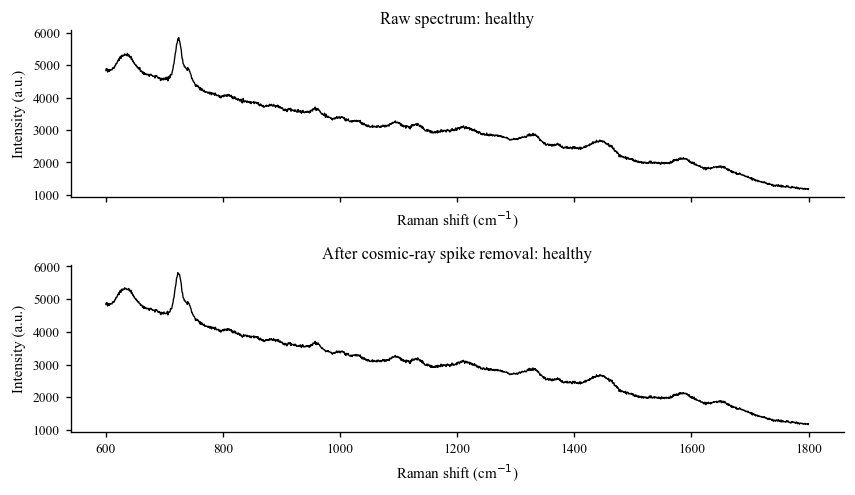

In [15]:
sample_label = 'healthy'
sample_row = raw_df[raw_df[LABEL_COLUMN] == sample_label].iloc[0]
raw_spectrum = sample_row[columns].to_numpy(dtype=float)
cleaned_spectrum = remove_cosmic_rays(raw_spectrum)

fig, axes = plt.subplots(2, 1, figsize=(7.2, 4.2), sharex=True)
axes[0].plot(x_axis, raw_spectrum, color='black', linewidth=0.8)
axes[0].set_title(f'Raw spectrum: {sample_label}', pad=4)
axes[1].plot(x_axis, cleaned_spectrum, color='black', linewidth=0.8)
axes[1].set_title(f'After cosmic-ray spike removal: {sample_label}', pad=4)
for ax in axes:
    style_axis(ax)
plt.tight_layout()
plt.show()


## Step 2: Savitzky-Golay smoothing

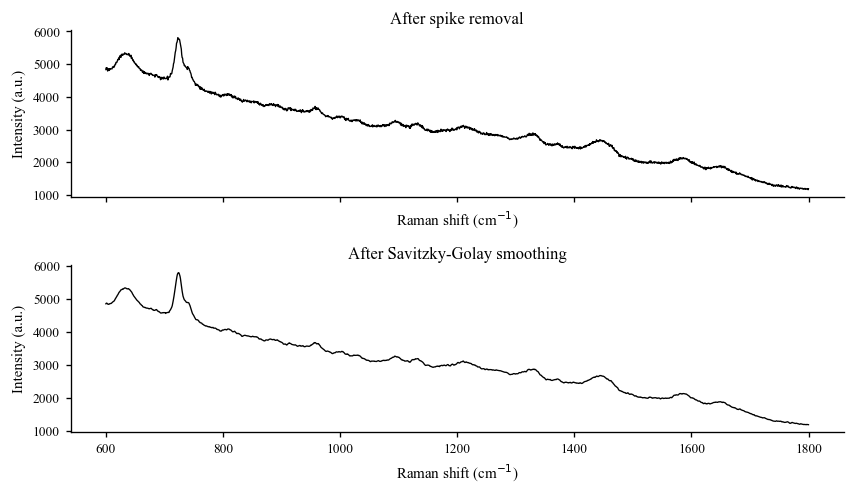

In [16]:
pre_cfg = config.get('preprocessing', {})
smoothing_window = int(pre_cfg.get('smoothing_window', 9))
if smoothing_window % 2 == 0:
    smoothing_window += 1
smoothing_polyorder = int(pre_cfg.get('smoothing_polyorder', 3))
smoothed_spectrum = savgol_filter(
    cleaned_spectrum,
    window_length=smoothing_window,
    polyorder=smoothing_polyorder,
)

fig, axes = plt.subplots(2, 1, figsize=(7.2, 4.2), sharex=True)
axes[0].plot(x_axis, cleaned_spectrum, color='black', linewidth=0.8)
axes[0].set_title('After spike removal', pad=4)
axes[1].plot(x_axis, smoothed_spectrum, color='black', linewidth=0.8)
axes[1].set_title('After Savitzky-Golay smoothing', pad=4)
for ax in axes:
    style_axis(ax)
plt.tight_layout()
plt.show()


## Step 3: IA-WPLS baseline correction

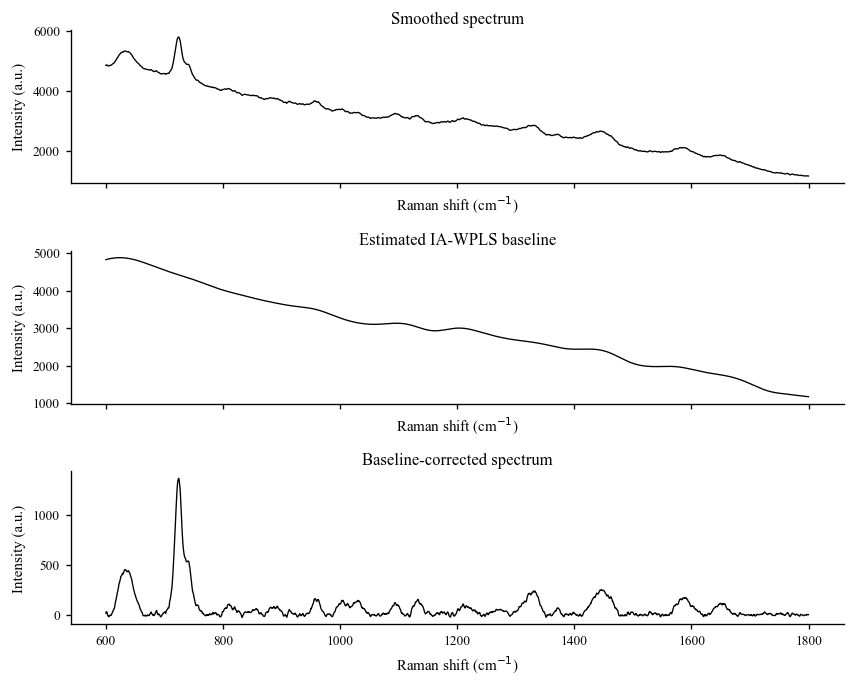

In [17]:
baseline, corrected = iawpls_baseline(
    smoothed_spectrum,
    order=int(pre_cfg.get('baseline_poly_order', 3)),
    iterations=int(pre_cfg.get('baseline_iterations', 100)),
    tolerance=float(pre_cfg.get('baseline_tolerance', 0.001)),
    smooth_window=int(pre_cfg.get('baseline_smooth_window', 9)),
)

fig, axes = plt.subplots(3, 1, figsize=(7.2, 5.8), sharex=True)
axes[0].plot(x_axis, smoothed_spectrum, color='black', linewidth=0.8)
axes[0].set_title('Smoothed spectrum', pad=4)
axes[1].plot(x_axis, baseline, color='black', linewidth=0.8)
axes[1].set_title('Estimated IA-WPLS baseline', pad=4)
axes[2].plot(x_axis, corrected, color='black', linewidth=0.8)
axes[2].set_title('Baseline-corrected spectrum', pad=4)
for ax in axes:
    style_axis(ax)
plt.tight_layout()
plt.show()


## Step 4: L2 normalization and full preprocessing

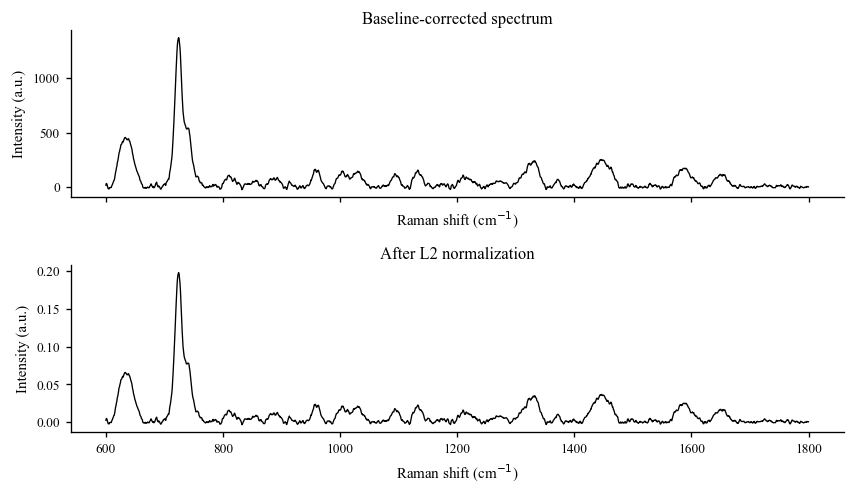

C:\Users\19447\AppData\Local\Temp\ipykernel_22216\718635850.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[columns] = spectra
C:\Users\19447\AppData\Local\Temp\ipykernel_22216\718635850.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[columns] = spectra
C:\Users\19447\AppData\Local\Temp\ipykernel_22216\718635850.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using

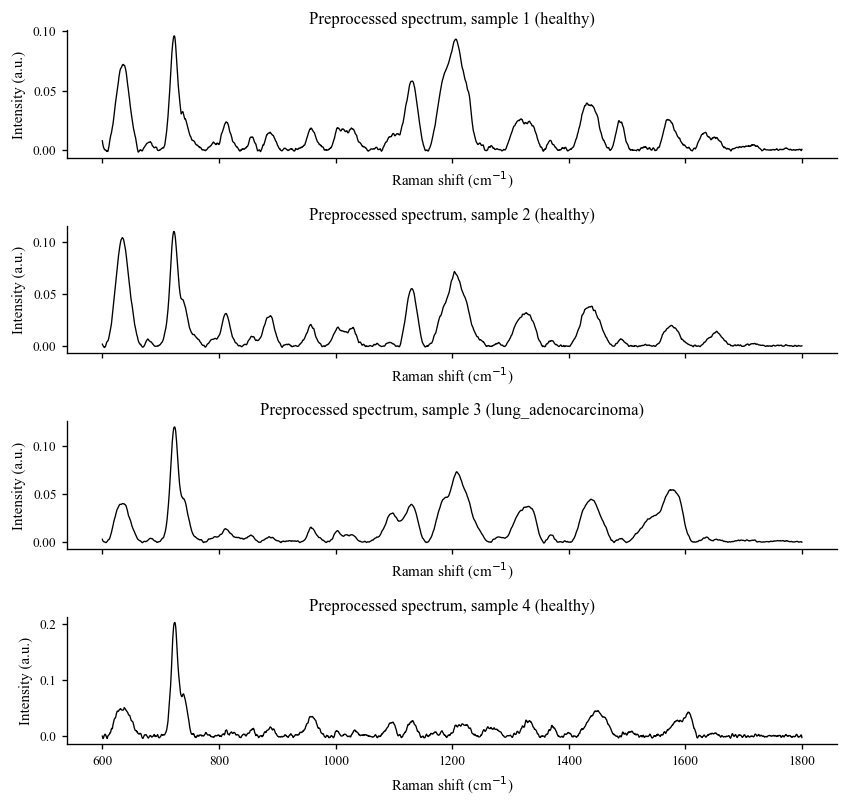

Saved preprocessing stages to:
C:\Users\19447\Desktop\LungAdenocarcinoma_Raman_Diffusion_Reproduction\data2\01_raw_spectra.csv
C:\Users\19447\Desktop\LungAdenocarcinoma_Raman_Diffusion_Reproduction\data2\02_cosmic_ray_removed.csv
C:\Users\19447\Desktop\LungAdenocarcinoma_Raman_Diffusion_Reproduction\data2\03_savgol_smoothed.csv
C:\Users\19447\Desktop\LungAdenocarcinoma_Raman_Diffusion_Reproduction\data2\04_iawpls_baseline.csv
C:\Users\19447\Desktop\LungAdenocarcinoma_Raman_Diffusion_Reproduction\data2\05_baseline_corrected.csv
C:\Users\19447\Desktop\LungAdenocarcinoma_Raman_Diffusion_Reproduction\data2\06_l2_normalized.csv


In [18]:
norm = np.linalg.norm(corrected)
normalized = corrected / norm if norm > 0 else corrected

fig, axes = plt.subplots(2, 1, figsize=(7.2, 4.2), sharex=True)
axes[0].plot(x_axis, corrected, color='black', linewidth=0.8)
axes[0].set_title('Baseline-corrected spectrum', pad=4)
axes[1].plot(x_axis, normalized, color='black', linewidth=0.8)
axes[1].set_title('After L2 normalization', pad=4)
for ax in axes:
    style_axis(ax)
plt.tight_layout()
plt.show()


def dataframe_from_spectra(template_df: pd.DataFrame, spectra: np.ndarray) -> pd.DataFrame:
    result = template_df[[LABEL_COLUMN]].copy()
    result[columns] = spectra
    return result


def preprocess_spectra_with_intermediate_outputs(df: pd.DataFrame, preprocessing_config: dict) -> dict[str, pd.DataFrame]:
    spectra = df[columns].to_numpy(dtype=float)
    cleaned_all = np.zeros_like(spectra, dtype=float)
    smoothed_all = np.zeros_like(spectra, dtype=float)
    baseline_all = np.zeros_like(spectra, dtype=float)
    corrected_all = np.zeros_like(spectra, dtype=float)
    normalized_all = np.zeros_like(spectra, dtype=float)

    window = int(preprocessing_config.get('smoothing_window', 9))
    if window % 2 == 0:
        window += 1
    polyorder = int(preprocessing_config.get('smoothing_polyorder', 3))
    baseline_order = int(preprocessing_config.get('baseline_poly_order', 3))
    baseline_iterations = int(preprocessing_config.get('baseline_iterations', 100))
    baseline_tolerance = float(preprocessing_config.get('baseline_tolerance', 0.001))
    baseline_smooth_window = int(preprocessing_config.get('baseline_smooth_window', 9))

    for index, spectrum in enumerate(spectra):
        cleaned = remove_cosmic_rays(spectrum)
        smoothed = savgol_filter(cleaned, window_length=window, polyorder=polyorder)
        baseline_i, corrected_i = iawpls_baseline(
            smoothed,
            order=baseline_order,
            iterations=baseline_iterations,
            tolerance=baseline_tolerance,
            smooth_window=baseline_smooth_window,
        )
        norm_i = np.linalg.norm(corrected_i)
        normalized_i = corrected_i / norm_i if norm_i > 0 else corrected_i

        cleaned_all[index] = cleaned
        smoothed_all[index] = smoothed
        baseline_all[index] = baseline_i
        corrected_all[index] = corrected_i
        normalized_all[index] = normalized_i

    return {
        '01_raw_spectra.csv': df.copy(),
        '02_cosmic_ray_removed.csv': dataframe_from_spectra(df, cleaned_all),
        '03_savgol_smoothed.csv': dataframe_from_spectra(df, smoothed_all),
        '04_iawpls_baseline.csv': dataframe_from_spectra(df, baseline_all),
        '05_baseline_corrected.csv': dataframe_from_spectra(df, corrected_all),
        '06_l2_normalized.csv': dataframe_from_spectra(df, normalized_all),
    }


stage_dfs = preprocess_spectra_with_intermediate_outputs(raw_df, pre_cfg)
for filename, stage_df in stage_dfs.items():
    stage_df.to_csv(DATA2_DIR / filename, index=False)

processed_df = stage_dfs['06_l2_normalized.csv']
plot_random_spectra(processed_df, 'Preprocessed spectrum', n=4, random_state=seed)

print('Saved preprocessing stages to:')
for filename in stage_dfs:
    print(DATA2_DIR / filename)

## Step 5: Stratified split check

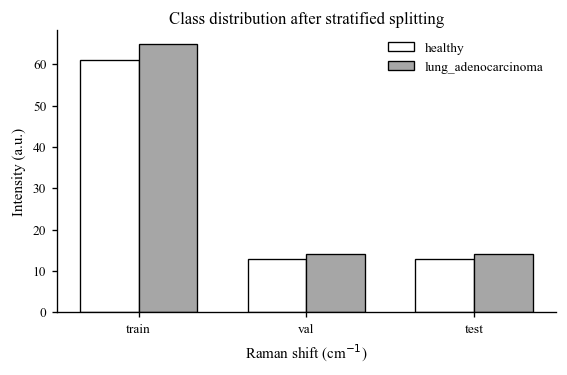

train {'lung_adenocarcinoma': 65, 'healthy': 61}
val {'lung_adenocarcinoma': 14, 'healthy': 13}
test {'lung_adenocarcinoma': 14, 'healthy': 13}


In [19]:
split_cfg = config.get('split', {})
train_idx, val_idx, test_idx = stratified_split(
    processed_df,
    float(split_cfg.get('train_ratio', 0.7)),
    float(split_cfg.get('val_ratio', 0.15)),
    float(split_cfg.get('test_ratio', 0.15)),
    seed,
)

splits = {
    'train': processed_df.iloc[train_idx],
    'val': processed_df.iloc[val_idx],
    'test': processed_df.iloc[test_idx],
}

fig, ax = plt.subplots(figsize=(4.8, 3.2))
labels = list(splits.keys())
healthy_counts = [int((df[LABEL_COLUMN] == 'healthy').sum()) for df in splits.values()]
cancer_counts = [int((df[LABEL_COLUMN] == 'lung_adenocarcinoma').sum()) for df in splits.values()]
x = np.arange(len(labels))
width = 0.35
ax.bar(x - width / 2, healthy_counts, width, label='healthy', color='white', edgecolor='black', linewidth=0.8)
ax.bar(x + width / 2, cancer_counts, width, label='lung_adenocarcinoma', color='0.65', edgecolor='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title('Class distribution after stratified splitting', pad=4)
ax.set_ylabel('Number of spectra')
ax.legend(frameon=False)
style_axis(ax)
plt.tight_layout()
plt.show()

for name, df in splits.items():
    print(name, df[LABEL_COLUMN].value_counts().to_dict())


## Step 6: Save split outputs to data2

This cell writes the final normalized matrix, NumPy archive, split indices, and split CSV files to the `data2` directory.

In [20]:
processed_csv = DATA2_DIR / 'raman_spectra_preprocessed.csv'
processed_npz = DATA2_DIR / 'processed_spectra.npz'
split_json = DATA2_DIR / 'split_indices.json'

processed_df.to_csv(processed_csv, index=False)
save_npz(processed_df, processed_npz, config.get('classes', {'healthy': 0, 'lung_adenocarcinoma': 1}))
split_indices = {'train': train_idx, 'val': val_idx, 'test': test_idx}
split_json.write_text(json.dumps(split_indices, ensure_ascii=False, indent=2), encoding='utf-8')
save_split_csvs(processed_df, split_indices, DATA2_DIR)

summary = {
    'output_dir': str(DATA2_DIR),
    'stage_files': [str(DATA2_DIR / filename) for filename in stage_dfs],
    'processed_csv': str(processed_csv),
    'processed_npz': str(processed_npz),
    'split_indices': str(split_json),
    'split_csvs': {
        'train': str(DATA2_DIR / 'train.csv'),
        'val': str(DATA2_DIR / 'val.csv'),
        'test': str(DATA2_DIR / 'test.csv'),
    },
    'counts': processed_df[LABEL_COLUMN].value_counts().to_dict(),
    'splits': {name: len(rows) for name, rows in split_indices.items()},
}

(DATA2_DIR / 'prepare_summary.json').write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding='utf-8')
summary

{'output_dir': 'C:\\Users\\19447\\Desktop\\LungAdenocarcinoma_Raman_Diffusion_Reproduction\\data2',
 'stage_files': ['C:\\Users\\19447\\Desktop\\LungAdenocarcinoma_Raman_Diffusion_Reproduction\\data2\\01_raw_spectra.csv',
  'C:\\Users\\19447\\Desktop\\LungAdenocarcinoma_Raman_Diffusion_Reproduction\\data2\\02_cosmic_ray_removed.csv',
  'C:\\Users\\19447\\Desktop\\LungAdenocarcinoma_Raman_Diffusion_Reproduction\\data2\\03_savgol_smoothed.csv',
  'C:\\Users\\19447\\Desktop\\LungAdenocarcinoma_Raman_Diffusion_Reproduction\\data2\\04_iawpls_baseline.csv',
  'C:\\Users\\19447\\Desktop\\LungAdenocarcinoma_Raman_Diffusion_Reproduction\\data2\\05_baseline_corrected.csv',
  'C:\\Users\\19447\\Desktop\\LungAdenocarcinoma_Raman_Diffusion_Reproduction\\data2\\06_l2_normalized.csv'],
 'processed_csv': 'C:\\Users\\19447\\Desktop\\LungAdenocarcinoma_Raman_Diffusion_Reproduction\\data2\\raman_spectra_preprocessed.csv',
 'processed_npz': 'C:\\Users\\19447\\Desktop\\LungAdenocarcinoma_Raman_Diffusion_Re